## Данные и EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re
import ast
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
DATA_PATH = '../data/raw/recipes.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Размер датасета: {df.shape[0]} рецептов, {df.shape[1]} колонок")
print(f"\nПервые 3 строки:")
display(df.head(3))

Размер датасета: 1090 рецептов, 15 колонок

Первые 3 строки:


,Unnamed: 0,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src
0,0,Apple-Cranberry Crostada,NaN,NaN,NaN,8,6 to 8 - servings,"3 tablespoons butter, 2 pounds Granny Smith ap...",Heat butter in a large skillet over medium-hig...,4.4,https://www.allrecipes.com/recipe/76931/apple-...,/Desserts/Fruit Desserts/Apple Dessert Recipes/,"Total Fat 18g 23%, Saturated Fat 7g 34%, Chole...","Servings: 8, Yield: 6 to 8 - servings",https://www.allrecipes.com/thmb/Tf1wH73bfH6Oql...
1,1,Apple Pie by Grandma Ople,30 mins,1 hrs,1 hrs 30 mins,8,1 9-inch pie,"8 small Granny Smith apples, or as needed, ½ c...","Peel and core apples, then thinly slice. Set a...",4.8,https://www.allrecipes.com/recipe/12682/apple-...,/Desserts/Pies/Apple Pie Recipes/,"Total Fat 19g 24%, Saturated Fat 9g 46%, Chole...","Prep Time: 30 mins, Cook Time: 1 hrs, Total Ti...",https://www.allrecipes.com/thmb/1I95oiTGz6aEpu...
2,2,Sarah's Homemade Applesauce,10 mins,15 mins,25 mins,4,NaN,"4 apples - peeled, cored and chopped, ¾ cup w...","Combine apples, water, sugar, and cinnamon in ...",4.8,https://www.allrecipes.com/recipe/51301/sarahs...,/Side Dish/Applesauce Recipes/,"Total Fat 0g 0%, Sodium 3mg 0%, Total Carbohyd...","Prep Time: 10 mins, Cook Time: 15 mins, Total ...",https://www.allrecipes.com/thmb/VY5d0tZHB8xz6y...


### Первичный анализ

In [3]:
# Базовая статистика
print(df.info())
print(f"\nПропущенные значения:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1090 non-null   int64  
 1   recipe_name   1090 non-null   object 
 2   prep_time     1039 non-null   object 
 3   cook_time     782 non-null    object 
 4   total_time    1045 non-null   object 
 5   servings      1090 non-null   int64  
 6   yield         879 non-null    object 
 7   ingredients   1090 non-null   object 
 8   directions    1090 non-null   object 
 9   rating        1090 non-null   float64
 10  url           1090 non-null   object 
 11  cuisine_path  1090 non-null   object 
 12  nutrition     1090 non-null   object 
 13  timing        1090 non-null   object 
 14  img_src       1090 non-null   object 
dtypes: float64(1), int64(2), object(12)
memory usage: 127.9+ KB
None

Пропущенные значения:
cook_time      308
yield          211
prep_time       51
total_time  

In [4]:
print("Колонки в датасете:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

Колонки в датасете:
  - Unnamed: 0: int64
  - recipe_name: object
  - prep_time: object
  - cook_time: object
  - total_time: object
  - servings: int64
  - yield: object
  - ingredients: object
  - directions: object
  - rating: float64
  - url: object
  - cuisine_path: object
  - nutrition: object
  - timing: object
  - img_src: object


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print("\nСтатистика по числовым колонкам:")
    display(df[numeric_cols].describe())


Статистика по числовым колонкам:


,Unnamed: 0,servings,rating
count,1090.000000,1090.000000,1090.000000
mean,544.500000,13.755046,4.533853
std,314.800201,19.886076,0.349814
min,0.000000,1.000000,2.000000
25%,272.250000,6.000000,4.400000
50%,544.500000,8.000000,4.600000
75%,816.750000,12.000000,4.700000
max,1089.000000,240.000000,5.000000


### Очистка данных

In [6]:
def parse_ingredients(value):
    """Превращает строковое представление списка в реальный список."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            # Пробуем распарсить как Python-литерал
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            # Если не вышло — разбиваем по переносам/запятым
            return [item.strip() for item in re.split(r'[\n,]', value) if item.strip()]
    return []

In [7]:
df['ingredients_list'] = df['ingredients'].apply(parse_ingredients)

In [8]:
df['n_ingredients'] = df['ingredients_list'].apply(len)
print(f"Статистика по количеству ингредиентов на рецепт:")
print(df['n_ingredients'].describe())

Статистика по количеству ингредиентов на рецепт:
count    1090.000000
mean       10.180734
std         4.494604
min         1.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        32.000000
Name: n_ingredients, dtype: float64


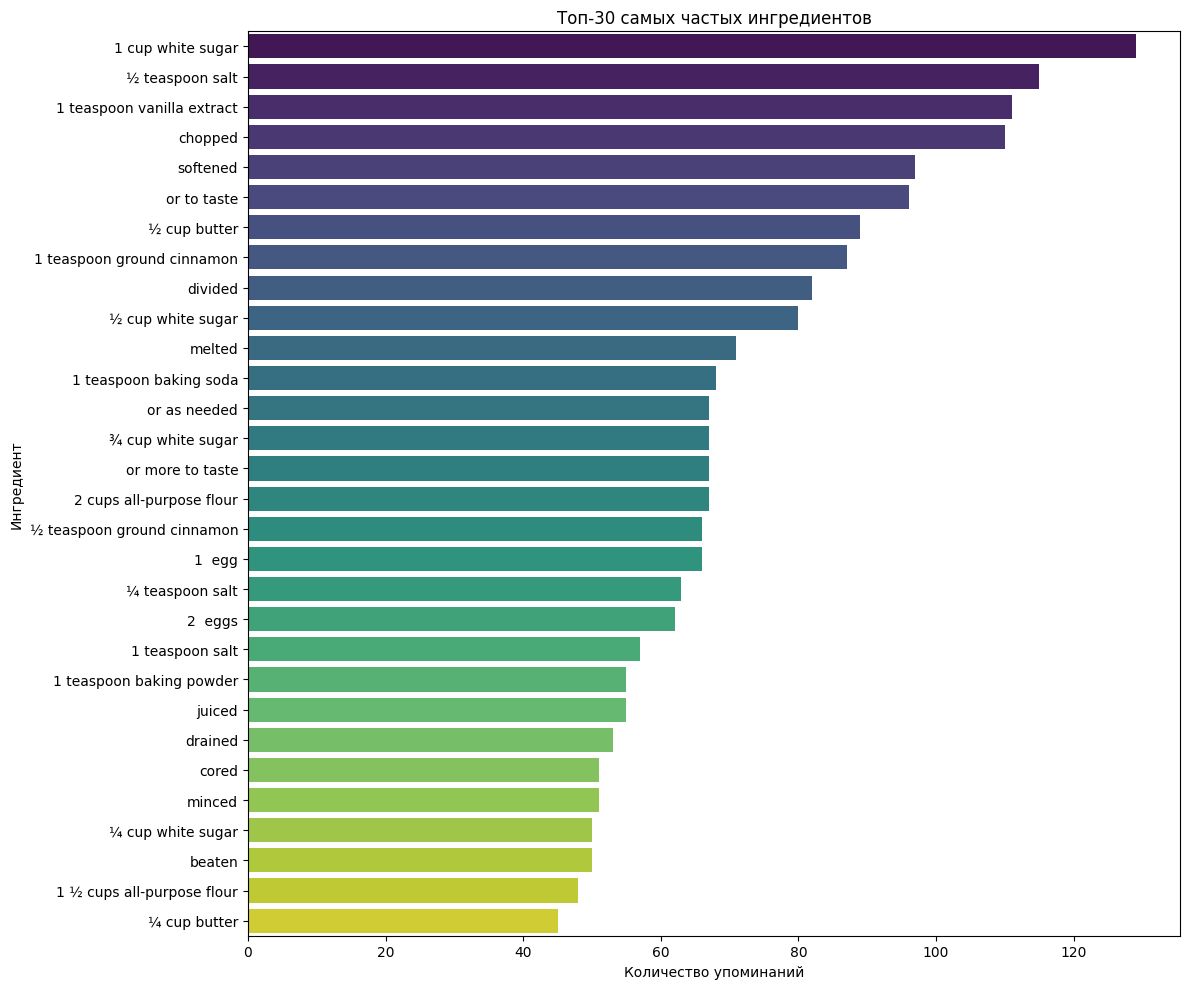

In [9]:
# Собираем все ингредиенты в один список
all_ingredients = []
for ing_list in df['ingredients_list']:
    all_ingredients.extend([ing.lower().strip() for ing in ing_list if isinstance(ing, str)])

# Считаем частоты
ingredient_freq = Counter(all_ingredients)
top_ingredients = ingredient_freq.most_common(50)

# Визуализация топ-30
plt.figure(figsize=(12, 10))
top_30 = top_ingredients[:30]
ingredients, counts = zip(*top_30)
sns.barplot(x=counts, y=ingredients, palette='viridis')
plt.title('Топ-30 самых частых ингредиентов')
plt.xlabel('Количество упоминаний')
plt.ylabel('Ингредиент')
plt.tight_layout()
plt.savefig('../artifacts/figures/top_30_ingredients.png', dpi=300, bbox_inches='tight')

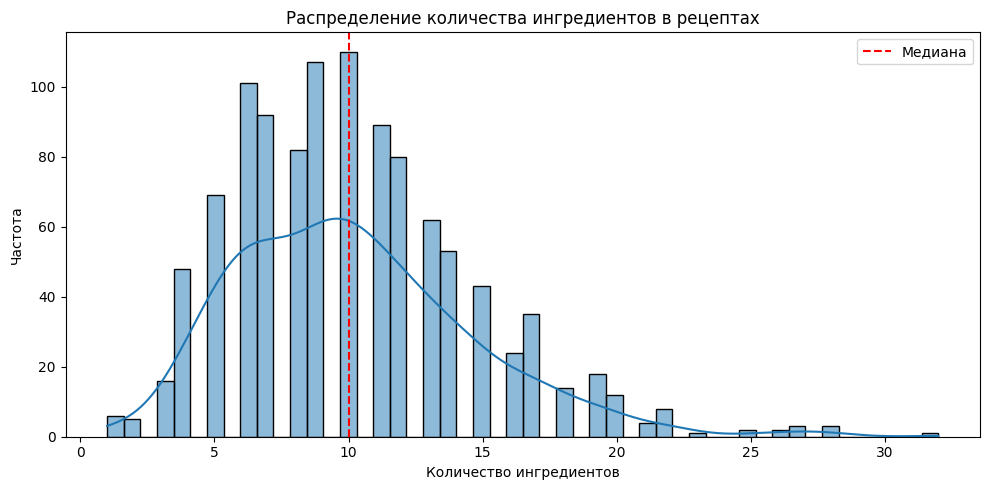

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['n_ingredients'], bins=50, kde=True)
plt.title('Распределение количества ингредиентов в рецептах')
plt.xlabel('Количество ингредиентов')
plt.ylabel('Частота')
plt.axvline(df['n_ingredients'].median(), color='red', linestyle='--', label='Медиана')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/figures/ingredient_amount_distribution.png', dpi=300, bbox_inches='tight')

In [11]:
def clean_ingredient(ingredient: str) -> str:
    """Удаляет количества, единицы и описания, оставляя базовое название."""
    if not isinstance(ingredient, str):
        return ""
    
    text = ingredient.lower().strip()
    
    # Удаляем текст в скобках
    text = re.sub(r'\([^)]*\)', '', text)
    
    # Удаляем числа и единицы измерения
    text = re.sub(r'\b\d+[\.\d]*\s*(cups?|tbsp|tsp|tablespoons?|teaspoons?|oz|ounces?|'
                  r'grams?|kg|pounds?|lbs?|pieces?|slices?|cloves?|bunches?|'
                  r'pinch|dash|can|cans?|package|packages?)\b', '', text, flags=re.IGNORECASE)
    
    # Удаляем описательные слова
    text = re.sub(r'\b(fresh|frozen|dried|canned|chopped|minced|sliced|diced|'
                  r'grated|crushed|whole|large|small|medium|optional|to taste)\b', 
                  '', text, flags=re.IGNORECASE)
    
    # Удаляем лишние пробелы и спецсимволы
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [12]:
# Применяем очистку
df['ingredients_clean'] = df['ingredients_list'].apply(
    lambda lst: [clean_ingredient(ing) for ing in lst if clean_ingredient(ing)]
)

In [13]:
all_clean = []
for ing_list in df['ingredients_clean']:
    all_clean.extend(ing_list)
clean_freq = Counter(all_clean)

print(f"Топ-20 очищенных ингредиентов:")
for ing, count in clean_freq.most_common(20):
    print(f"  {ing}: {count}")


Топ-20 очищенных ингредиентов:
  white sugar: 301
  all purpose flour: 177
  vanilla extract: 161
  ground cinnamon: 160
  butter: 138
  salt: 128
  ½ teaspoon salt: 116
  lemon juice: 105
  water: 104
  2 eggs: 100
  or: 99
  softened: 97
  baking powder: 97
  1 egg: 93
  ½ cup butter: 89
  baking soda: 85
  divided: 82
  ½ cup white sugar: 81
  milk: 77
  garlic: 74


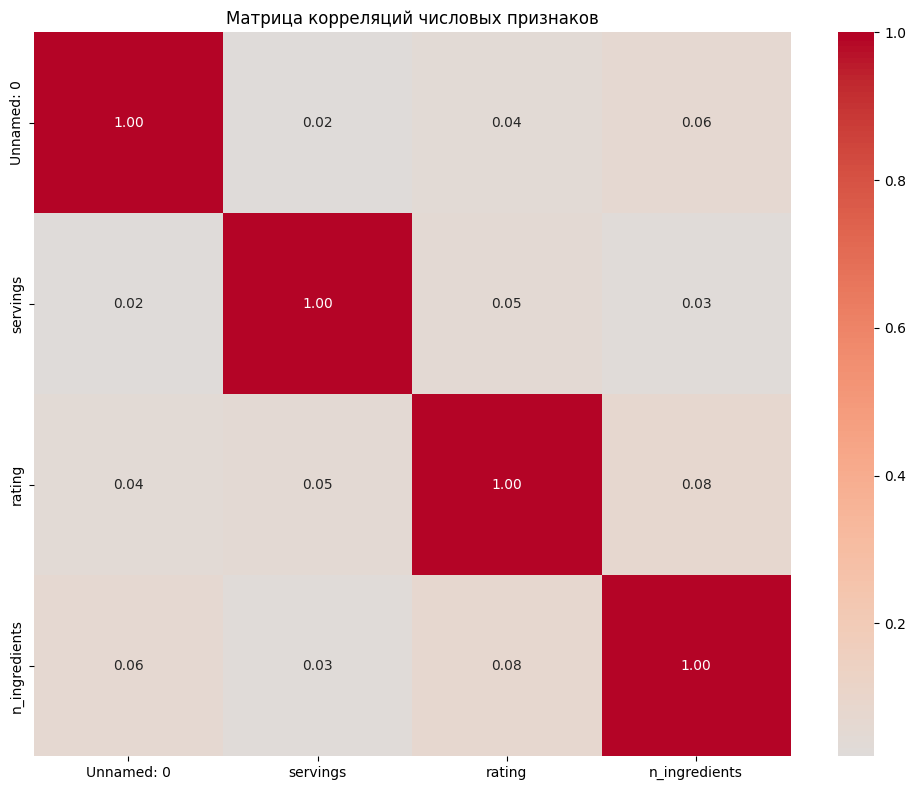

In [14]:
# Матрица корреляций для числовых признаков
numeric_for_corr = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
if numeric_for_corr.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    corr = numeric_for_corr.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Матрица корреляций числовых признаков')
    plt.tight_layout()
    plt.savefig('../artifacts/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')

In [15]:
def create_search_text(row):
    parts = []
    
    if 'recipe_name' in row and pd.notna(row['recipe_name']):
        parts.append(str(row['recipe_name']).lower())
    
    if 'ingredients_clean' in row:
        parts.extend(row['ingredients_clean'])
    
    return ' '.join(filter(None, parts))

df['search_text'] = df.apply(create_search_text, axis=1)

print(f"Пример поискового текста:\n{df['search_text'].iloc[0][:200]}...")

Пример поискового текста:
apple-cranberry crostada butter granny smith apples or other firm crisp apples peeled quartered cored and 1 4 inch thick macintosh apples peeled quartered cored and 1 4 inch thick ½ cup sugar ½ cup cr...


### Сохранение обработанных данных

In [16]:
cols_to_save = [
    'recipe_name', 'ingredients', 'ingredients_list', 'ingredients_clean',
    'search_text', 'cuisine_path', 'cuisine_main', 'cuisine_sub',
    'total_time', 'rating', 'url'
]
# Оставляем только существующие колонки
cols_to_save = [c for c in cols_to_save if c in df.columns]

# Сохраняем в Parquet
output_path = '../data/processed/recipes_processed.parquet'
df[cols_to_save].to_parquet(output_path, index=False)
print(f"Обработанные данные сохранены в: {output_path}")

Обработанные данные сохранены в: ../data/processed/recipes_processed.parquet


###  Генерация обучающих примеров

In [17]:
def generate_training_samples(df, n_samples_per_recipe=3, dropout_rate=0.3, min_query_len=2):
    """Генерирует пары для обучения ранжирования."""
    samples = []
    
    for idx, row in df.iterrows():
        ingredients = row.get('ingredients_clean', [])
        if len(ingredients) < 3:
            continue
        
        for _ in range(n_samples_per_recipe):
            # Случайно убираем часть ингредиентов
            query = [ing for ing in ingredients if np.random.random() > dropout_rate]
            
            if len(query) < min_query_len:
                continue
            
            samples.append({
                'query_ingredients': query,
                'query_text': ' '.join(query),
                'target_recipe_id': idx,
                'target_name': row.get('recipe_name'),
                'relevance': 1.0,
                'total_time': row.get('total_time'),
                'rating': row.get('rating'),
            })
    
    return pd.DataFrame(samples)

In [18]:
train_samples = generate_training_samples(df)
train_path = '../data/processed/training_queries.parquet'
train_samples.to_parquet(train_path, index=False)
print(f"Сгенерировано {len(train_samples)} обучающих примеров  {train_path}")

Сгенерировано 3203 обучающих примеров  ../data/processed/training_queries.parquet
